# Libraries and palettes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex

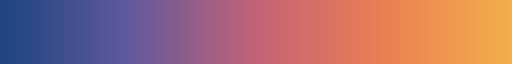

In [3]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')
sunset2

# Comprobations of RN Generation

mean: 0.99885400118
std: 0    0.52125
dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


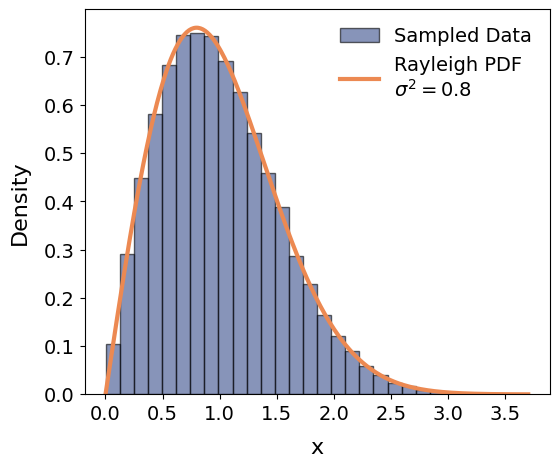

In [4]:
rayleigh_sample = pd.read_csv('test_rayleigh.txt', header = None)
print("mean:", np.mean(rayleigh_sample))
print("std:", np.std(rayleigh_sample))

mean = 1.0;
sigma = mean * np.sqrt(2.0 / np.pi);
the_x = np.arange(np.min(rayleigh_sample), np.max(rayleigh_sample), 0.01)
the_y = (the_x / (sigma**2)) * np.exp(- (the_x**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(rayleigh_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Rayleigh PDF\n' r'$\sigma^2 = 0.8$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)


mean: 0.29989812412
std: 0    0.039984
dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


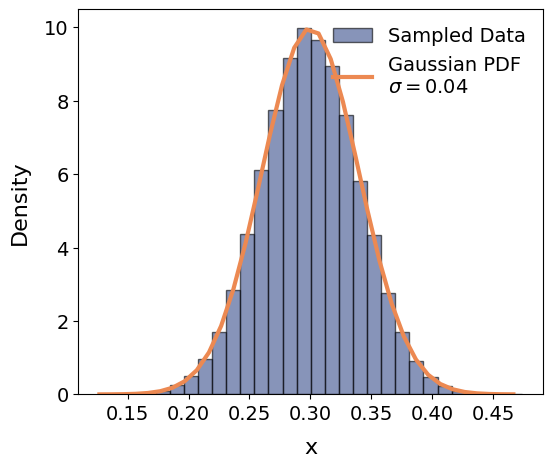

In [6]:
gaussian_sample = pd.read_csv('test_gaussian.txt', header = None)
print("mean:", np.mean(gaussian_sample))
print("std:", np.std(gaussian_sample))

mean = 0.3;
sigma = 0.04;
the_x = np.arange(np.min(gaussian_sample), np.max(gaussian_sample), 0.01)
the_y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(- ((the_x - mean)**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(gaussian_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Gaussian PDF\n' r'$\sigma = 0.04$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)


# Neuronal network

C:\Users\Admin\AppData\Local\Temp\ipykernel_15624\550006672.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("neurons_params.txt", delim_whitespace=True)


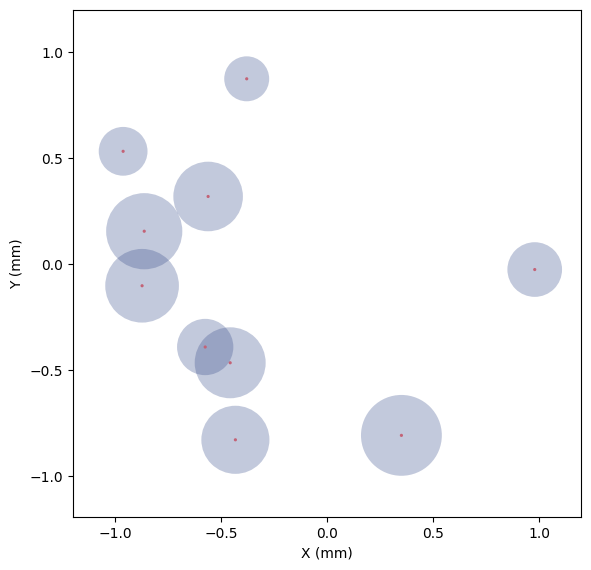

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Carga de datos: adapta el separador y el nombre del fichero
# Si es un .csv con comas:
# df = pd.read_csv("neuronas.txt")

# Si es un txt con espacios/tabuladores:
df = pd.read_csv("neurons_params.txt", delim_whitespace=True)

sub = df.head(10)

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in sub.iterrows():
    x = row["X"]
    y = row["Y"]
    soma_r = row["Soma_Diameter"] / 2.0          # mm
    dend_r = row["Dendrite_Diameter"] / 2.0      # mm

    # Círculo de dendritas (más grande y transparente)
    dend = Circle(
        (x, y),
        radius=dend_r,
        facecolor=sunset2(0.1),   # sin relleno, solo borde
        alpha=0.3
    )
    ax.add_patch(dend)

    # Círculo del soma (más pequeño y relleno)
    soma = Circle(
        (x, y),
        radius=soma_r,
        facecolor=sunset2(0.5),
        lw=0.8
    )
    ax.add_patch(soma)

# Límites del gráfico: dejamos un pequeño margen según el tamaño de las dendritas
max_r = (df["Dendrite_Diameter"] / 2.0).max()
xmin = df["X"].min() - max_r
xmax = df["X"].max() + max_r
ymin = df["Y"].min() - max_r
ymax = df["Y"].max() + max_r

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")

plt.tight_layout()
plt.show()
